In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
dataset=pd.read_csv('slip_3.csv')
print(dataset.columns)

Index(['name_of_city', 'state_code', 'state_name', 'dist_code',
       'population_total', 'population_male', 'population_female',
       '0-6_population_total', '0-6_population_male', '0-6_population_female',
       'literates_total', 'literates_male', 'literates_female', 'sex_ratio',
       'child_sex_ratio', 'effective_literacy_rate_total',
       'effective_literacy_rate_male', 'effective_literacy_rate_female',
       'location', 'total_graduates', 'male_graduates', 'female_graduates'],
      dtype='object')


In [79]:
X=dataset.iloc[:,[19,15]].values

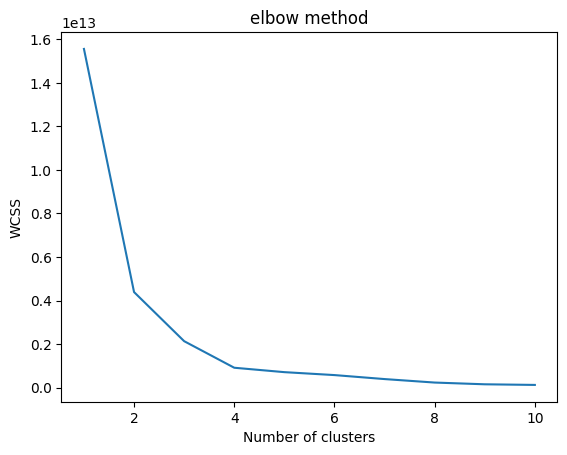

In [80]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title("elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [83]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [84]:
y_pred=kmeans.predict(X)

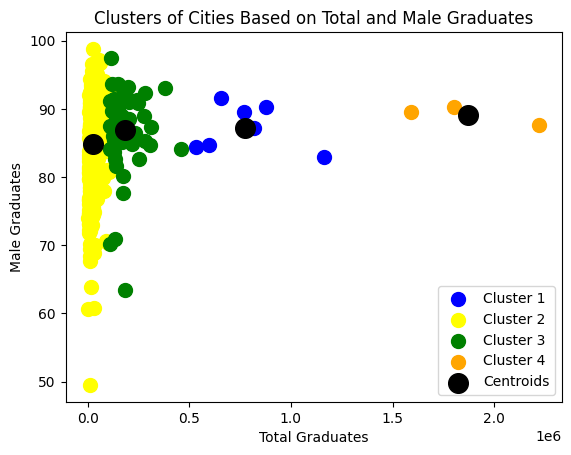

In [88]:
plt.scatter(X[y_pred==0,0],X[y_pred==0,1],s=100,c='Blue',label='Cluster 1')
plt.scatter(X[y_pred==1,0],X[y_pred==1,1],s=100,c='Yellow',label='Cluster 2')
plt.scatter(X[y_pred==2,0],X[y_pred==2,1],s=100,c='Green',label='Cluster 3')
plt.scatter(X[y_pred==3,0],X[y_pred==3,1],s=100,c='Orange',label='Cluster 4')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200,c='Black',label='Centroids')
plt.title("Clusters of Cities Based on Total and Male Graduates")
plt.xlabel("Total Graduates")
plt.ylabel("Male Graduates")
plt.legend()
plt.show()

In [90]:

from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_pred)
print(f"Silhouette Score for k=4: ",round(score,2))


Silhouette Score for k=4:  0.81
